In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

%matplotlib inline

In [2]:
df = pd.read_csv('E_Clash_Royale_Cards.csv')

In [3]:
df.shape

(120, 13)

In [4]:
df.size

1560

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               120 non-null    str    
 1   maxEvolutionLevel  38 non-null     float64
 2   elixirCost         119 non-null    float64
 3   iconUrls           120 non-null    str    
 4   evolutionIcons     38 non-null     str    
 5   rarity             120 non-null    str    
 6   type               120 non-null    str    
 7   mobility           120 non-null    str    
 8   targets            120 non-null    str    
 9   attack_type        119 non-null    str    
 10  groupCard          120 non-null    bool   
 11  usage              119 non-null    float64
 12  hitpoints          101 non-null    float64
dtypes: bool(1), float64(4), str(8)
memory usage: 11.5 KB


In [6]:
df.isnull().sum()

name                  0
maxEvolutionLevel    82
elixirCost            1
iconUrls              0
evolutionIcons       82
rarity                0
type                  0
mobility              0
targets               0
attack_type           1
groupCard             0
usage                 1
hitpoints            19
dtype: int64

In [7]:
df.head()

,name,maxEvolutionLevel,elixirCost,iconUrls,evolutionIcons,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints
0,Archer Queen,NaN,5.0,https://api-assets.clashroyale.com/cards/300/p...,NaN,champion,troop,ground,ground,single,False,6.48,1000.0
1,Archers,1.0,3.0,https://api-assets.clashroyale.com/cards/300/W...,https://api-assets.clashroyale.com/cardevoluti...,common,troop,ground,both,single,True,1.44,304.0
2,Arrows,NaN,3.0,https://api-assets.clashroyale.com/cards/300/F...,NaN,common,spell,flying,both,splash,False,30.64,NaN
3,Baby Dragon,1.0,4.0,https://api-assets.clashroyale.com/cards/300/c...,https://api-assets.clashroyale.com/cardevoluti...,epic,troop,flying,both,splash,False,4.64,1152.0
4,Balloon,NaN,5.0,https://api-assets.clashroyale.com/cards/300/q...,NaN,epic,troop,flying,buildings,single,False,7.52,1679.0


In [8]:
print(df.columns.tolist())

['name', 'maxEvolutionLevel', 'elixirCost', 'iconUrls', 'evolutionIcons', 'rarity', 'type', 'mobility', 'targets', 'attack_type', 'groupCard', 'usage', 'hitpoints']


In [9]:
cols = ['iconUrls', 'evolutionIcons']

df.drop(cols, axis = 1, inplace = True)

In [10]:
df.head()

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints
0,Archer Queen,NaN,5.0,champion,troop,ground,ground,single,False,6.48,1000.0
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0
2,Arrows,NaN,3.0,common,spell,flying,both,splash,False,30.64,NaN
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0
4,Balloon,NaN,5.0,epic,troop,flying,buildings,single,False,7.52,1679.0


In [11]:
df.isnull().sum()

name                  0
maxEvolutionLevel    82
elixirCost            1
rarity                0
type                  0
mobility              0
targets               0
attack_type           1
groupCard             0
usage                 1
hitpoints            19
dtype: int64

In [12]:
# Fill missing data in numeric columns with the median (middle value).
# This is ideal for skewed data as it is not affected by extreme outliers.
df['maxEvolutionLevel'] = df['maxEvolutionLevel'].fillna(0)
df['elixirCost'] = df['elixirCost'].fillna(df['elixirCost'].median())
df['usage'] = df['usage'].fillna(df['usage'].median())


# Fill missing data in the text column with the mode (most frequent value). 
# Is required because .mode() returns a Series, and extracts the top value.
df['attack_type'] = df['attack_type'].fillna(df['attack_type'].mode()[0])

In [13]:
# NaN in hitpoints means "not applicable" (spells don't have HP), not a data gap.
# So instead of filling it with a fake value, we create a separate flag column
# to mark which rows actually have hitpoints — troops/buildings = True, spells = False.

# WRONG - this OVERWRITES the real hitpoints numbers with True/False, losing the data
# df['hitpoints'] = df['hitpoints'].notna()

# CORRECT - creates a brand new column, original hitpoints values stay untouched
df['has_hitpoints'] = df['hitpoints'].notna()

# Now you have both:
# - hitpoints: the real HP values (with NaN for spells, left as-is)
# - has_hitpoints: True/False flag you can filter on later
# e.g. df[df['has_hitpoints']] gives you only cards with real HP (excludes spells)

In [14]:
df.head()

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True
4,Balloon,0.0,5.0,epic,troop,flying,buildings,single,False,7.52,1679.0,True


In [15]:
df.isnull().sum()

name                  0
maxEvolutionLevel     0
elixirCost            0
rarity                0
type                  0
mobility              0
targets               0
attack_type           0
groupCard             0
usage                 0
hitpoints            19
has_hitpoints         0
dtype: int64

##### **Basic filtering & sorting**

##### 1. Find all cards with `elixirCost` greater than 5.

In [16]:
df.head(4)

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True


In [17]:
higher_elixir = df[df['elixirCost'] > 5]

# First df checks row by row if this elixirCost greater than 5?
# The result is just a list of answers: [False, False, True, False, True]

# Go back to the original stack (df), look at my list of answers.
# Pull out the cards that matched.

higher_elixir[['name','elixirCost',]]

,name,elixirCost
7,Barbarian Hut,6.0
15,Boss Bandit,6.0
24,Electro Giant,7.0
27,Elite Barbarians,6.0
28,Elixir Collector,6.0
39,Giant Skeleton,6.0
47,Goblin Giant,6.0
53,Golem,8.0
65,Lava Hound,7.0
66,Lightning,6.0


##### 2. Find the top 5 cards by `hitpoints`.

In [18]:
df.head(4)

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True


In [19]:
top5_hitpoints = df.sort_values('hitpoints', ascending = False).head(5)
# sort_values('hitpoints', ascending=False): Rearranges your rows from the highest hitpoints to lowest.
# .head(5): Grabs only the top 5 rows from that sorted list.
# top5_hitpoints =: Saves these top 5 records into a new, smaller DataFrame.

top5_hitpoints[['name','hitpoints']]
# [['name', 'hitpoints']]: Hides all other columns (like usage or elixir cost) and 
# displays only the identity (name) and health (hitpoints) of those top 5 cards.

,name,hitpoints
53,Golem,5120.0
38,Giant,4090.0
70,Mega Knight,3993.0
24,Electro Giant,3855.0
83,P.E.K.K.A,3760.0


##### 3. Find all cards of `rarity == "Legendary"` and display only `name`, `elixirCost`, `usage`.

In [20]:
df.head(4)

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True


In [21]:
df['rarity'].value_counts()

rarity
epic         33
rare         30
common       29
legendary    20
champion      8
Name: count, dtype: int64

In [22]:
rare_legendcard = df[df['rarity'] == "legendary"]
rare_legendcard[['name','elixirCost','usage']]

,name,elixirCost,usage
5,Bandit,3.0,9.60
26,Electro Wizard,4.0,9.84
34,Fisherman,3.0,4.00
49,Goblin Machine,5.0,0.88
54,Graveyard,5.0,3.44
61,Ice Wizard,3.0,7.20
62,Inferno Dragon,4.0,8.16
65,Lava Hound,7.0,2.40
68,Lumberjack,4.0,4.32
69,Magic Archer,4.0,4.08


##### **Grouping & aggregation**

##### 4. What is the average `elixirCost` for each `rarity`?

In [23]:
df.head(4)

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True


In [24]:
df.groupby('rarity')['elixirCost'].mean()

# df.groupby('rarity') — groups all rows by their rarity value
# ['elixirCost'] — selects just the usage column from each group
# .mean() — computes the average within each group

rarity
champion     4.500000
common       3.137931
epic         4.303030
legendary    4.150000
rare         4.100000
Name: elixirCost, dtype: float64

##### 5. What is the average `usage` for each `type` (Troop/Spell/Building)?

In [25]:
df.head()

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True
4,Balloon,0.0,5.0,epic,troop,flying,buildings,single,False,7.52,1679.0,True


In [26]:
df.groupby('type')['usage'].mean()

# df.groupby('type') — groups all rows by their type value (troop/spell/building)
# ['usage'] — selects just the usage column from each group
# .mean() — computes the average within each group

type
building    3.420000
spell       8.901818
troop       4.668837
Name: usage, dtype: float64

##### 6. Which `rarity` has the highest average `hitpoints`?

In [27]:
df.head()

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True
4,Balloon,0.0,5.0,epic,troop,flying,buildings,single,False,7.52,1679.0,True


In [28]:
df.groupby('rarity')['hitpoints'].mean()

rarity
champion     1714.875000
common        724.538462
epic         1835.409091
legendary    1359.888889
rare         1122.000000
Name: hitpoints, dtype: float64

##### **Value counts / categorical**

##### 7. Count how many cards belong to each `rarity`.

In [29]:
df['rarity'].value_counts()

rarity
epic         33
rare         30
common       29
legendary    20
champion      8
Name: count, dtype: int64

##### 8. Count how many cards are `groupCard == True` vs `False`.

In [30]:
df.head()

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True
4,Balloon,0.0,5.0,epic,troop,flying,buildings,single,False,7.52,1679.0,True


In [31]:
df['groupCard'].value_counts()

groupCard
False    101
True      19
Name: count, dtype: int64

##### **Visualization (matplotlib/seaborn)**

##### 8. Plot a bar chart of average `elixirCost` by `rarity`.

In [32]:
df.head()

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True
4,Balloon,0.0,5.0,epic,troop,flying,buildings,single,False,7.52,1679.0,True


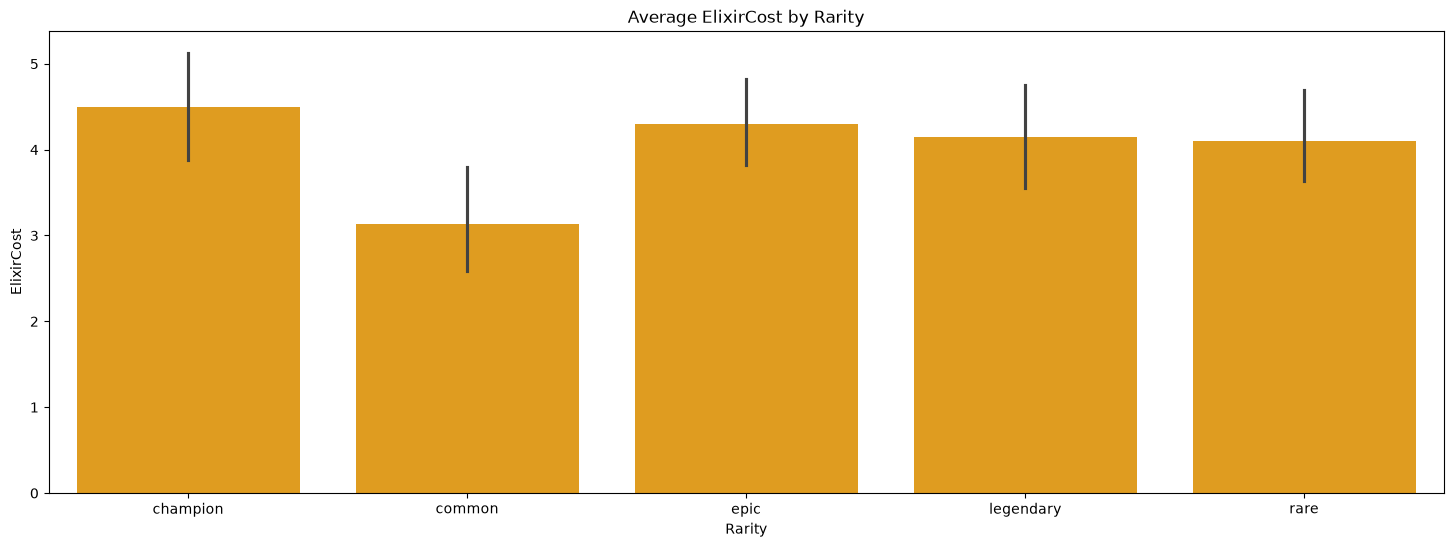

In [33]:
plt.figure(figsize=(18,6))

sns.barplot(x = 'rarity', y = 'elixirCost', data = df, color = 'orange')

plt.title('Average ElixirCost by Rarity')
plt.xlabel('Rarity')
plt.ylabel('ElixirCost')

plt.show()

##### 9. Plot a scatter plot of `elixirCost` vs `usage`, colored by `rarity`.

In [34]:
df.head()

,name,maxEvolutionLevel,elixirCost,rarity,type,mobility,targets,attack_type,groupCard,usage,hitpoints,has_hitpoints
0,Archer Queen,0.0,5.0,champion,troop,ground,ground,single,False,6.48,1000.0,True
1,Archers,1.0,3.0,common,troop,ground,both,single,True,1.44,304.0,True
2,Arrows,0.0,3.0,common,spell,flying,both,splash,False,30.64,NaN,False
3,Baby Dragon,1.0,4.0,epic,troop,flying,both,splash,False,4.64,1152.0,True
4,Balloon,0.0,5.0,epic,troop,flying,buildings,single,False,7.52,1679.0,True


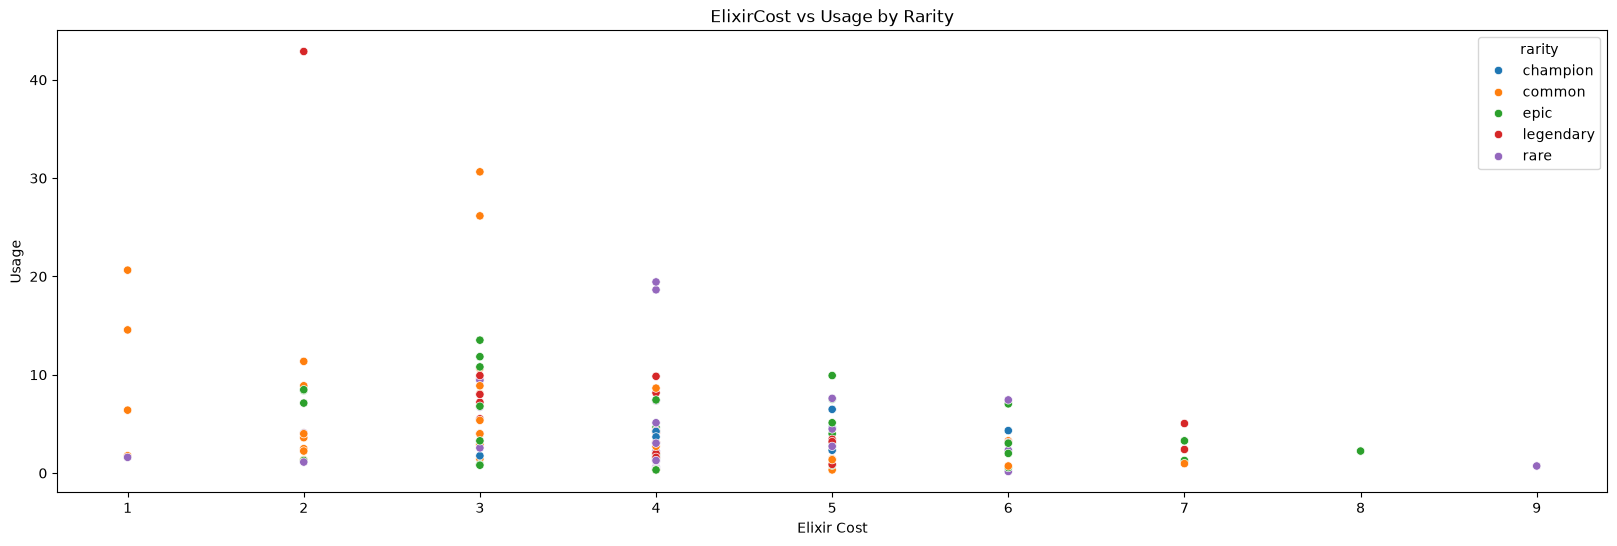

In [35]:
plt.figure(figsize=(20,6))

sns.scatterplot(x='elixirCost', y='usage', hue='rarity', data=df)
plt.title('ElixirCost vs Usage by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Usage')
plt.show()

##### 10. Handle missing `hitpoints` values (e.g., for Spells) — decide whether to fill or drop, and justify.

In [37]:
# hitpoints is NaN for spells (19 rows) — this isn't a data-entry gap, it's structural:
# spells don't have HP because they aren't units on the battlefield.
# Filling with mean/median would invent a fake HP for something that has none,
# which corrupts any later stats (avg HP by type, correlation, elixir_efficiency, etc).
# 
# Decision: leave hitpoints as NaN, and keep a flag column to filter spells out
# when doing HP-based analysis.
df['has_hitpoints'] = df['hitpoints'].notna()

##### 11. Create a new column `elixir_efficiency = hitpoints / elixirCost` and find the top 5 cards by this metric.

##### 12. Find the correlation between `elixirCost`, `usage`, and `hitpoints` using `.corr()`, and visualize it with a heatmap.